# Phân tích khám phá dữ liệu chia sẻ xe đạp tại Seoul

Notebook khảo sát phân phối số lượt thuê xe theo giờ và mối liên hệ giữa nhu cầu thuê với một số yếu tố thời tiết, thời gian và mùa. Đơn vị quan sát là một giờ; biến kết quả chính là `Rented Bike Count`.

Phạm vi phân tích được giới hạn ở những giờ hệ thống hoạt động (`Functioning Day = Yes`). Vì vậy, các kết quả mô tả nhu cầu trong thời gian dịch vụ vận hành, không đại diện cho các giờ hệ thống ngừng hoạt động.

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
df = pd.read_csv("../data/SeoulBikeData.csv")
source_row_count = len(df)


def clean_to_kebab_case(column_name: str) -> str:
    no_unit = re.sub(r"[\(\[].*?[\)\]]", "", column_name)
    clean_text = no_unit.strip()
    return re.sub(r"[\s_]+", "-", clean_text).lower()


df.attrs["friendly-name"] = {
    clean_to_kebab_case(column_name): column_name for column_name in df.columns
}
df = df.rename(columns=clean_to_kebab_case)
df["holiday"] = df["holiday"].map({"Holiday": 1, "No Holiday": 0}).astype(int)

functioning_day_count = df["functioning-day"].eq("Yes").sum()
df = df.loc[df["functioning-day"].eq("Yes")].drop(columns="functioning-day")


def get_friendly_name(column_name: str) -> str:
    return df.attrs["friendly-name"][column_name]


print(
    f"Giữ lại {functioning_day_count:,}/{source_row_count:,} quan sát "
    "trong các giờ hệ thống hoạt động."
)

In [42]:
df

,date,rented-bike-count,hour,temperature,humidity,wind-speed,visibility,dew-point-temperature,solar-radiation,rainfall,snowfall,seasons,holiday
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,0
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,0
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,0
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,0
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,0
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,0
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,0
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
Index: 8465 entries, 0 to 8759
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   8465 non-null   str    
 1   rented-bike-count      8465 non-null   int64  
 2   hour                   8465 non-null   int64  
 3   temperature            8465 non-null   float64
 4   humidity               8465 non-null   int64  
 5   wind-speed             8465 non-null   float64
 6   visibility             8465 non-null   int64  
 7   dew-point-temperature  8465 non-null   float64
 8   solar-radiation        8465 non-null   float64
 9   rainfall               8465 non-null   float64
 10  snowfall               8465 non-null   float64
 11  seasons                8465 non-null   str    
 12  holiday                8465 non-null   int64  
dtypes: float64(6), int64(5), str(2)
memory usage: 1.0 MB


In [14]:
quality_summary = pd.DataFrame(
    {
        "missing_values": df.isna().sum(),
        "unique_values": df.nunique(),
    }
)
display(quality_summary)
print(f"Số dòng trùng hoàn toàn: {df.duplicated().sum():,}")

,missing_values,unique_values
date,0,353
rented-bike-count,0,2165
hour,0,24
temperature,0,546
humidity,0,90
wind-speed,0,65
visibility,0,1780
dew-point-temperature,0,556
solar-radiation,0,345
rainfall,0,61


Số dòng trùng hoàn toàn: 0


## Phân tích xu hướng trung tâm

Trung bình, trung vị và mode được dùng để mô tả mức độ tập trung của các biến. Với biến số lượt thuê, các thước đo này giúp phân biệt mức nhu cầu điển hình với ảnh hưởng của những giờ có nhu cầu cao.

### Hàm phân tích dùng chung


In [7]:
def central_tendency_analysis(series: pd.Series) -> dict:
    return {
        "median": series.median(),
        "mean": series.mean(),
        "mode": series.mode().tolist()
    }



## Tiến hành gọi hàm với các cột để lấy kết qủa


In [ ]:
central_tendency_columns = [
    "rented-bike-count",
    "temperature",
    "humidity",
    "visibility",
    "holiday",
    "wind-speed",
]

for column_name in central_tendency_columns:
    result = central_tendency_analysis(df[column_name])
    print(f"{get_friendly_name(column_name)}: {result}")

==== Analysing "rented-bike-count" :
Central Tendency Analysis for "rented-bike-count" :
{'median': np.float64(542.0), 'mean': np.float64(729.1569994093326), 'mode': [122, 223, 262]}
==== Analysing "temperature" :
Central Tendency Analysis for "temperature" :
{'median': np.float64(13.5), 'mean': np.float64(12.77105729474306), 'mode': [19.1]}
==== Analysing "humidity" :
Central Tendency Analysis for "humidity" :
{'median': np.float64(57.0), 'mean': np.float64(58.14719432959244), 'mode': [97]}
==== Analysing "visibility" :
Central Tendency Analysis for "visibility" :
{'median': np.float64(1690.0), 'mean': np.float64(1433.8734790313054), 'mode': [2000]}
==== Analysing "holiday" :
Central Tendency Analysis for "holiday" :
{'median': np.float64(0.0), 'mean': np.float64(0.04819846426461902), 'mode': [0]}
==== Analysing "wind-speed" :
Central Tendency Analysis for "wind-speed" :
{'median': np.float64(1.5), 'mean': np.float64(1.7258830478440639), 'mode': [1.1]}


**Nhận xét:** Số lượt thuê có trung bình khoảng 729 lượt/giờ, cao hơn trung vị 542 lượt/giờ. Chênh lệch này gợi ý phân phối lệch phải: một số khung giờ có nhu cầu cao kéo giá trị trung bình lên. Do có nhiều giá trị đồng mốt, mode được trình bày dưới dạng danh sách thay vì chọn tùy ý một giá trị.

## Phân tích độ phân tán

Độ phân tán mô tả mức độ các quan sát trải rộng quanh trung tâm. Phân tích sử dụng độ lệch chuẩn, phương sai, khoảng biến thiên và khoảng tứ phân vị (IQR). IQR ít nhạy với các giá trị cực đoan hơn khoảng biến thiên và độ lệch chuẩn.

### Hàm dùng chung

In [13]:
def analyse_dispersion(series: pd.Series) -> dict:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return {
        "std": series.std(),
        "var": series.var(),
        "range": series.max() - series.min(),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
    }

### Tiến hành gọi hàm với các series mục tiêu để lấy và in kết quả

In [16]:
dispersion_columns = [
    "rented-bike-count",
    "temperature",
    "humidity",
    "wind-speed",
    "dew-point-temperature",
]

for column_name in dispersion_columns:
    result = analyse_dispersion(df[column_name])
    print(f"{get_friendly_name(column_name)}: {result}")

Rented Bike Count: {'std': np.float64(642.3511661067845), 'var': np.float64(412615.0205987459), 'range': np.int64(3554), 'q1': np.float64(214.0), 'q3': np.float64(1084.0), 'iqr': np.float64(870.0)}
Temperature(°C): {'std': np.float64(12.104374809817012), 'var': np.float64(146.5158895365326), 'range': np.float64(57.2), 'q1': np.float64(3.0), 'q3': np.float64(22.7), 'iqr': np.float64(19.7)}
Humidity(%): {'std': np.float64(20.484838657490283), 'var': np.float64(419.6286148234083), 'range': np.int64(98), 'q1': np.float64(42.0), 'q3': np.float64(74.0), 'iqr': np.float64(32.0)}
Wind speed (m/s): {'std': np.float64(1.0342811984074631), 'var': np.float64(1.0697375973791783), 'range': np.float64(7.4), 'q1': np.float64(0.9), 'q3': np.float64(2.3), 'iqr': np.float64(1.4)}
Dew point temperature(°C): {'std': np.float64(13.242398979977567), 'var': np.float64(175.36113074491092), 'range': np.float64(57.8), 'q1': np.float64(-5.1), 'q3': np.float64(15.2), 'iqr': np.float64(20.299999999999997)}


**Nhận xét:** Với số lượt thuê, khoảng tứ phân vị là 870 lượt/giờ (Q1 = 214; Q3 = 1.084), cho thấy 50% quan sát ở giữa vẫn trải rộng đáng kể. Vì nhu cầu có phân phối lệch, trung vị và IQR thường mô tả mức điển hình bền vững hơn trung bình và độ lệch chuẩn.

## Trực quan hóa phân phối

### Trực quan hóa bằng boxplot


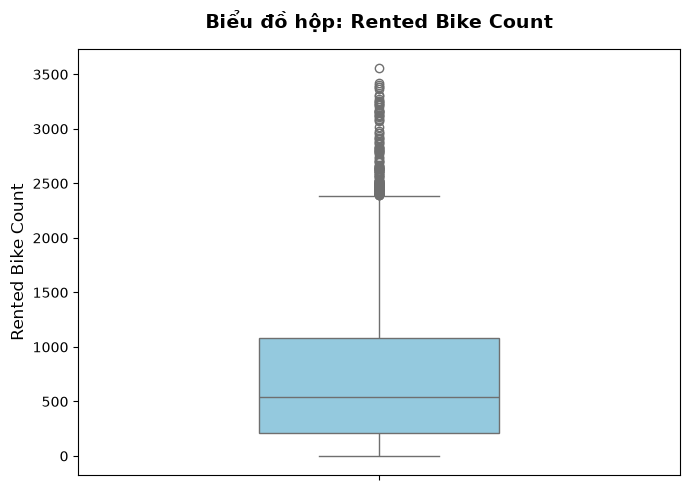

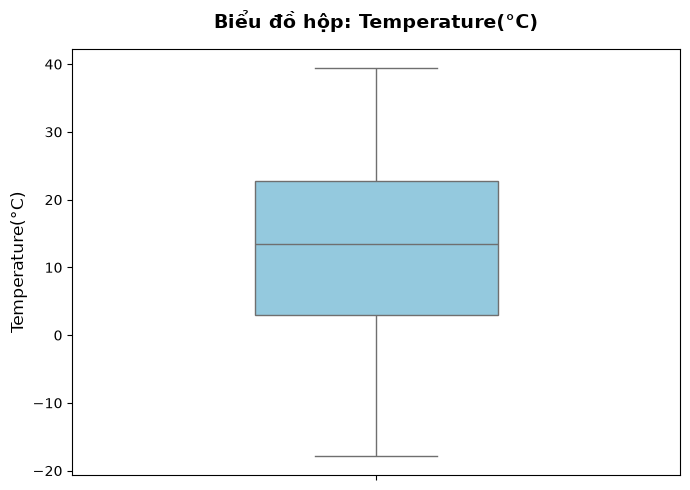

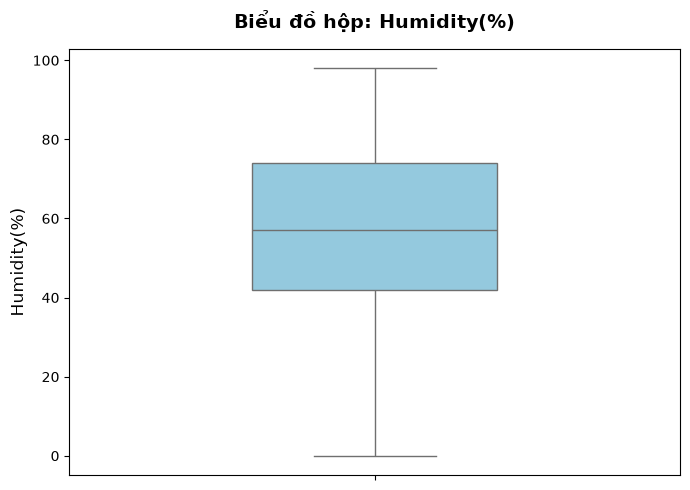

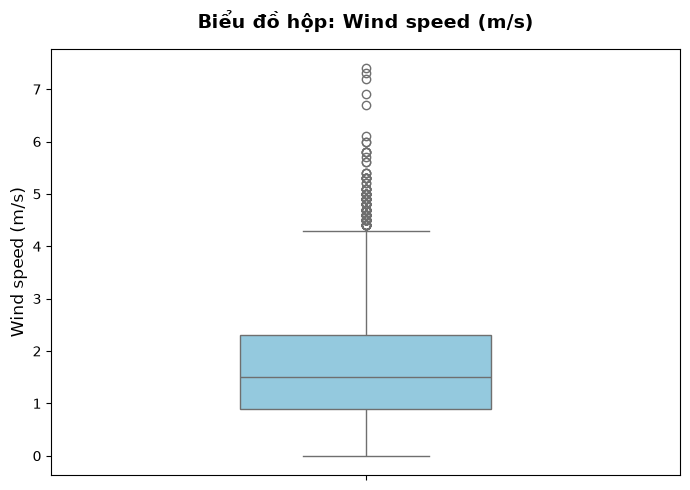

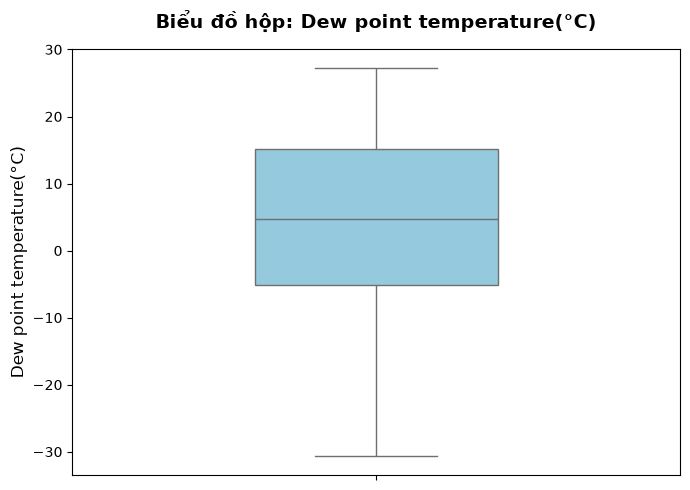

In [32]:
for column_name in dispersion_columns:
    friendly_name = get_friendly_name(column_name)
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, y=column_name, color="skyblue", width=0.4)
    plt.ylabel(friendly_name, fontsize=12)
    plt.title(f"Biểu đồ hộp: {friendly_name}", fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

### Trực quan hóa bằng histogram

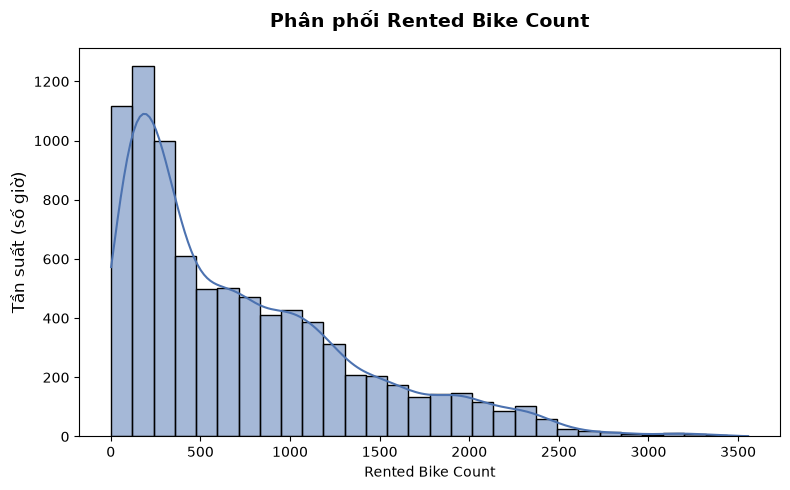

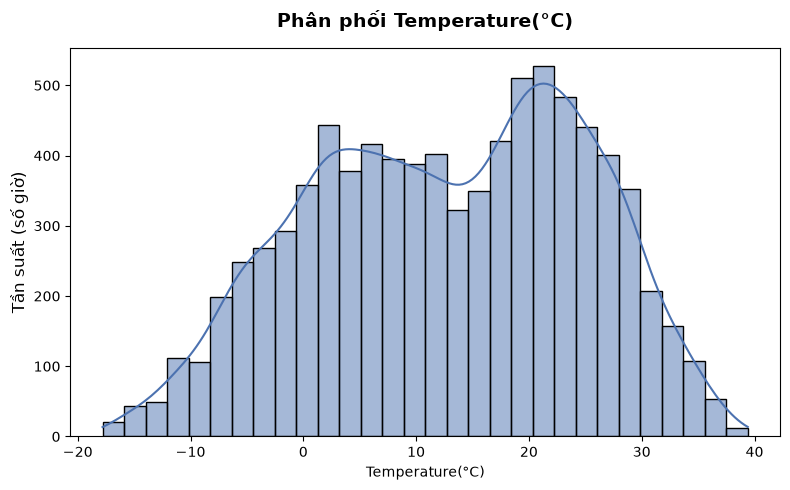

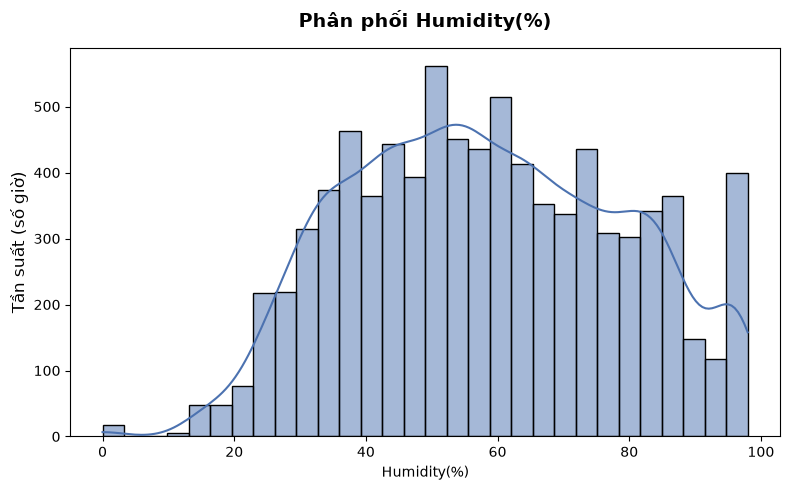

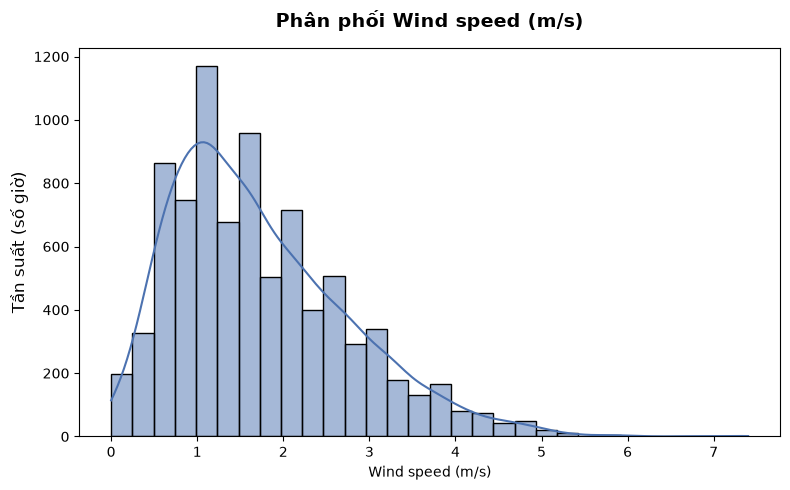

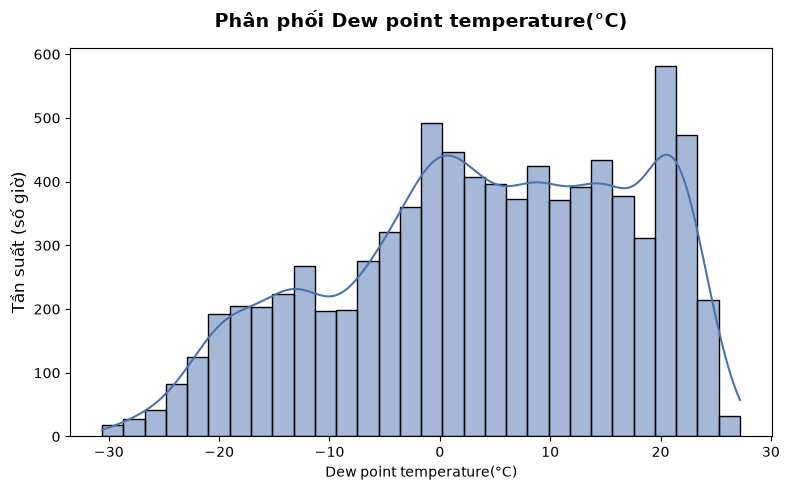

In [17]:
for column_name in dispersion_columns:
    friendly_name = get_friendly_name(column_name)
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df,
        x=column_name,
        bins=30,
        kde=True,
        color="#4C72B0",
        edgecolor="black",
    )
    plt.xlabel(friendly_name)
    plt.ylabel("Tần suất (số giờ)", fontsize=12)
    plt.title(f"Phân phối {friendly_name}", fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

### So sánh phân phối theo mùa

Biểu đồ violin thể hiện hình dạng phân phối của số lượt thuê và các biến thời tiết ở từng mùa; đường tứ phân vị hỗ trợ so sánh độ phân tán và trung vị giữa các nhóm.

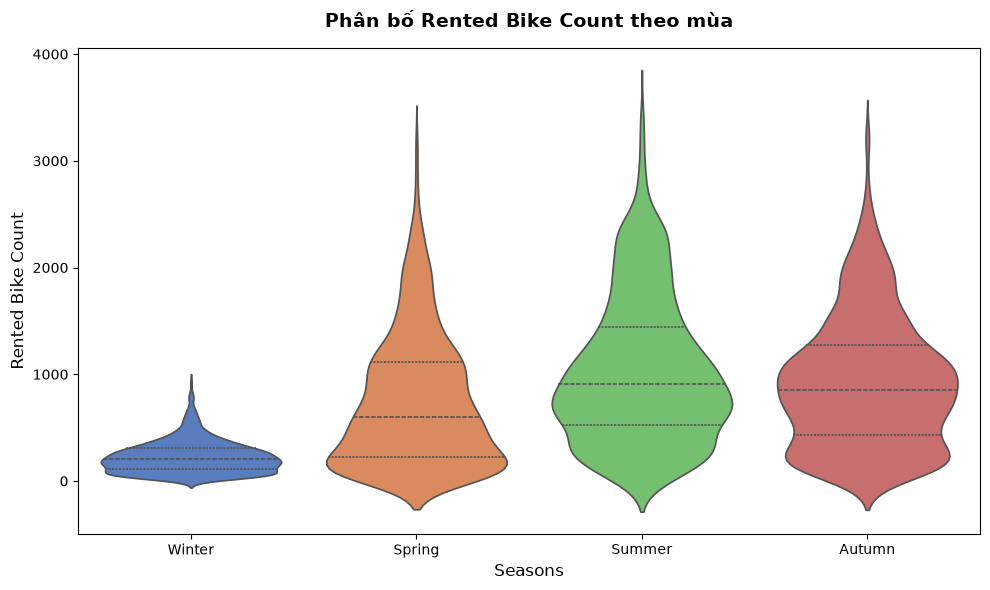

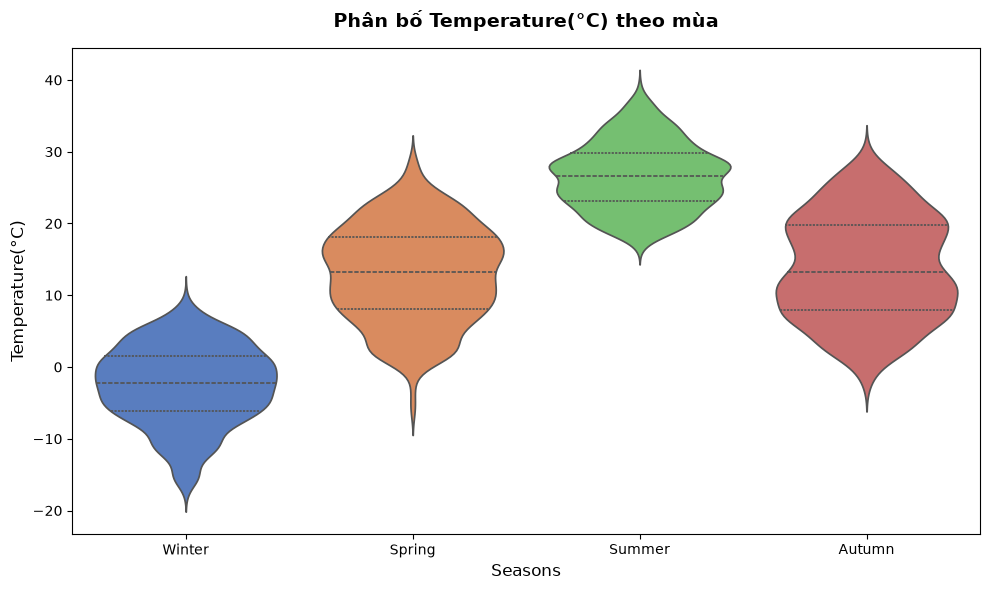

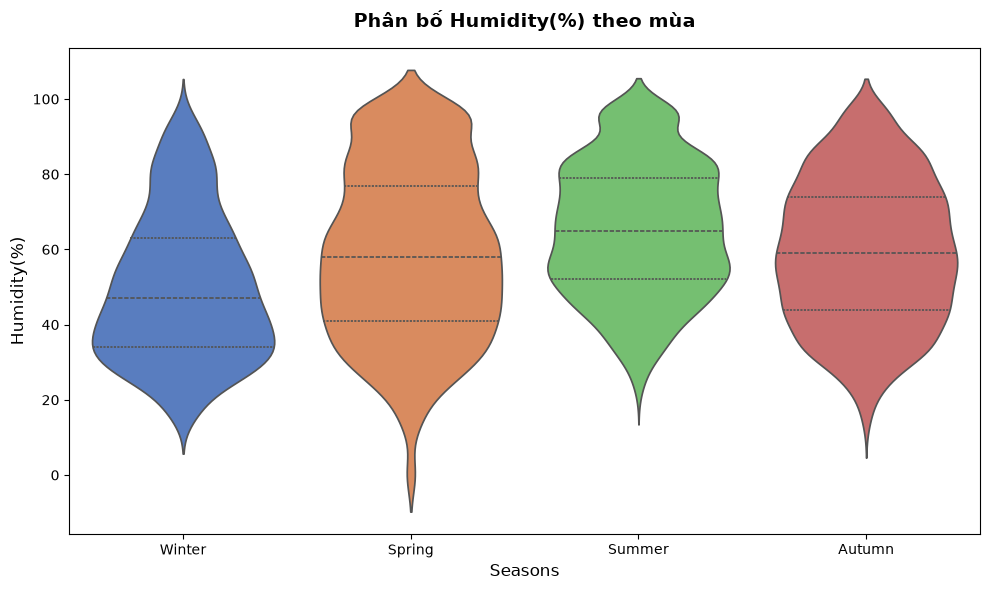

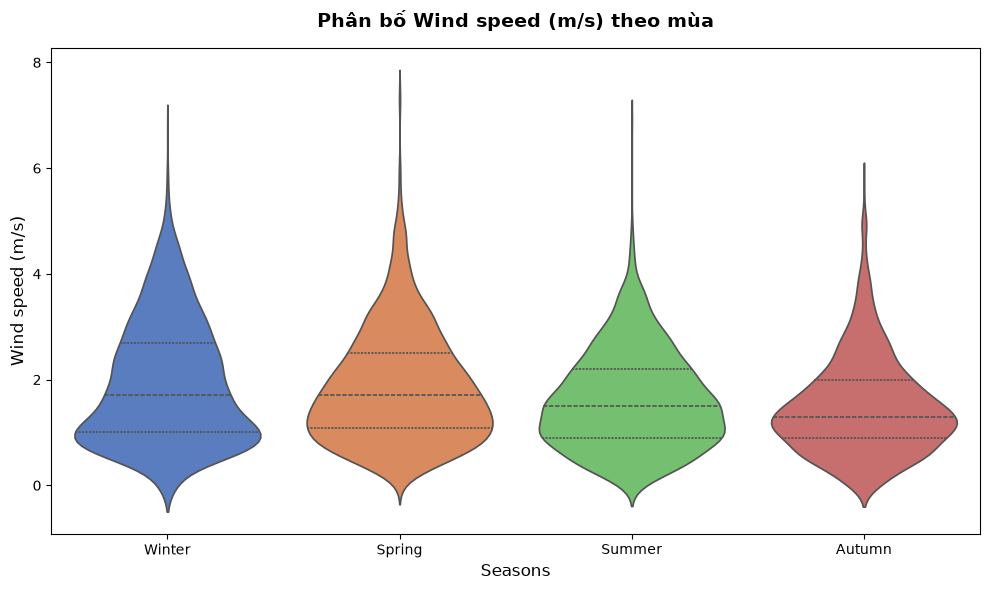

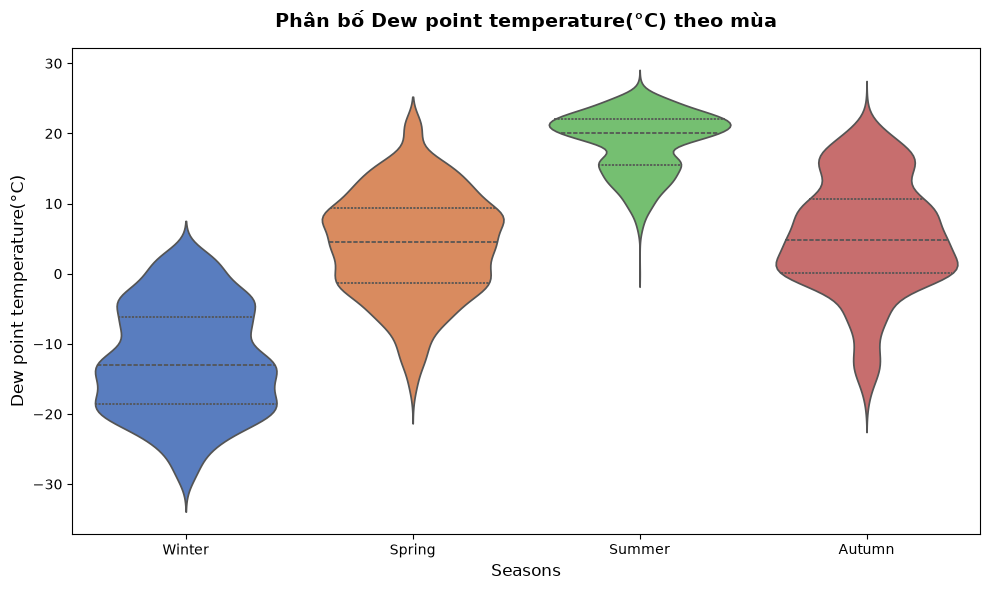

In [18]:
for column_name in dispersion_columns:
    friendly_name = get_friendly_name(column_name)
    plt.figure(figsize=(10, 6))
    sns.violinplot(
        data=df,
        x="seasons",
        y=column_name,
        inner="quartile",
        palette="muted",
        hue="seasons",
        legend=False,
    )
    plt.ylabel(friendly_name, fontsize=12)
    plt.xlabel(get_friendly_name("seasons"), fontsize=12)
    plt.title(f"Phân bố {friendly_name} theo mùa", fontsize=14, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()

## Hình dạng phân phối

Độ lệch (skewness) mô tả tính bất đối xứng của phân phối; độ nhọn (kurtosis) được báo cáo theo dạng excess kurtosis, trong đó phân phối chuẩn có giá trị xấp xỉ 0. Cần đối chiếu các chỉ số với biểu đồ vì chúng không thay thế việc quan sát dữ liệu.

In [20]:
def get_skew_and_kurt(series: pd.Series) -> dict:
    return {
        "skew": series.skew(),
        "kurtosis": series.kurtosis(),
    }

In [21]:
get_skew_and_kurt(df['rented-bike-count'])

{'skew': np.float64(1.1397000550865888),
 'kurtosis': np.float64(0.8203050394253548)}

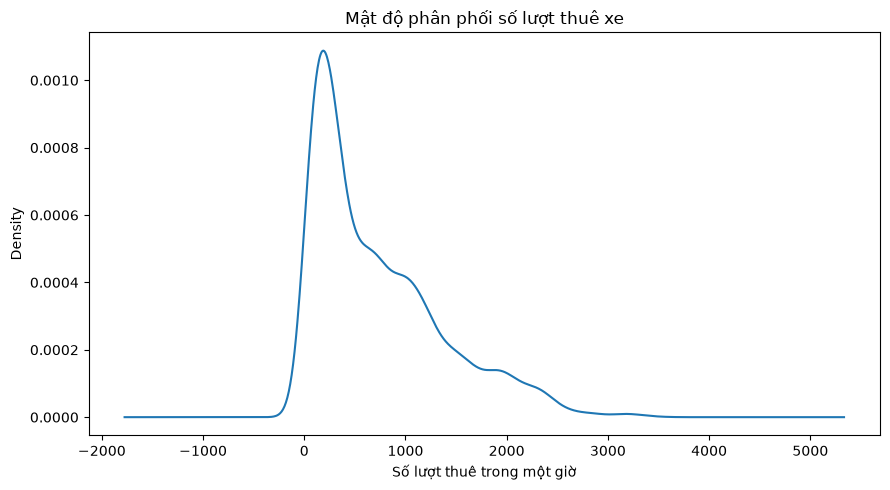

In [22]:
ax = df["rented-bike-count"].plot(kind="density", figsize=(9, 5))
ax.set_title("Mật độ phân phối số lượt thuê xe")
ax.set_xlabel("Số lượt thuê trong một giờ")
plt.tight_layout()
plt.show()

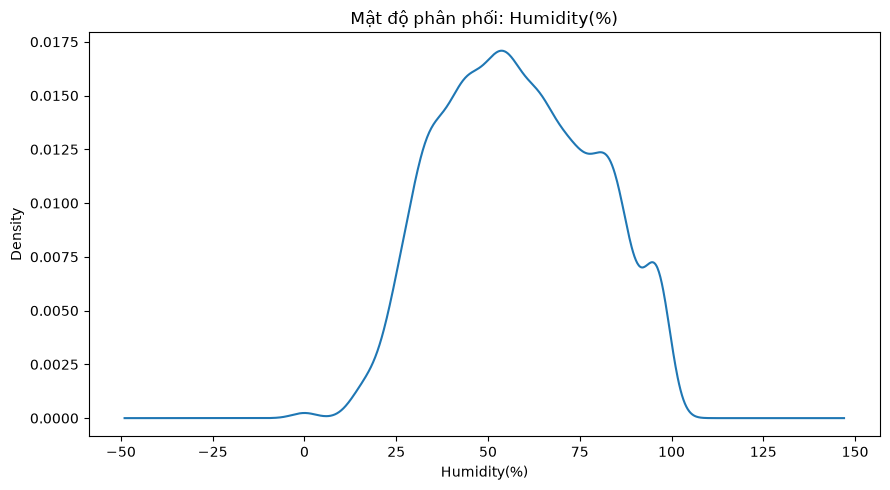

In [23]:
ax = df["humidity"].plot(kind="density", figsize=(9, 5))
ax.set_title(f"Mật độ phân phối: {get_friendly_name('humidity')}")
ax.set_xlabel(get_friendly_name("humidity"))
plt.tight_layout()
plt.show()

## Mối liên hệ giữa số lượt thuê và các yếu tố liên quan

Biểu đồ hồi quy và tương quan Pearson được dùng để khảo sát mối liên hệ tuyến tính giữa số lượt thuê với các biến số. Đây là phân tích khám phá; tương quan không chứng minh quan hệ nhân quả, và các biến thời gian/mùa có thể đồng biến với điều kiện thời tiết.

### Số lượt thuê theo từng biến

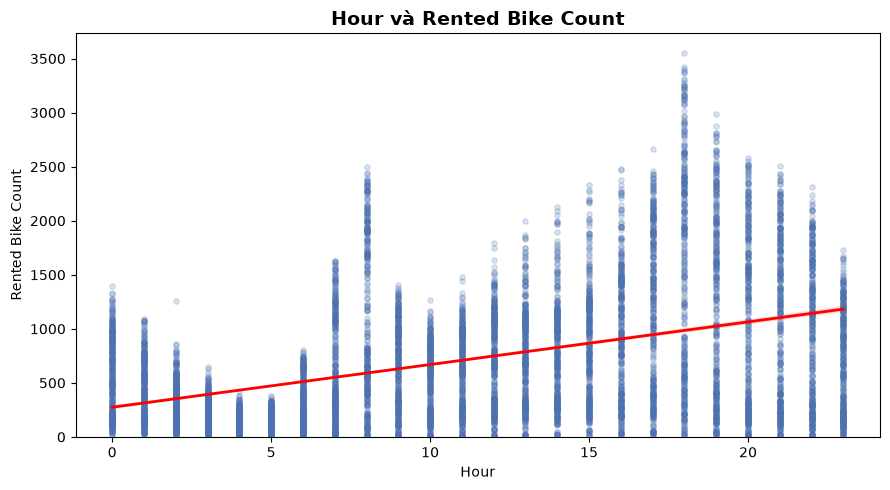

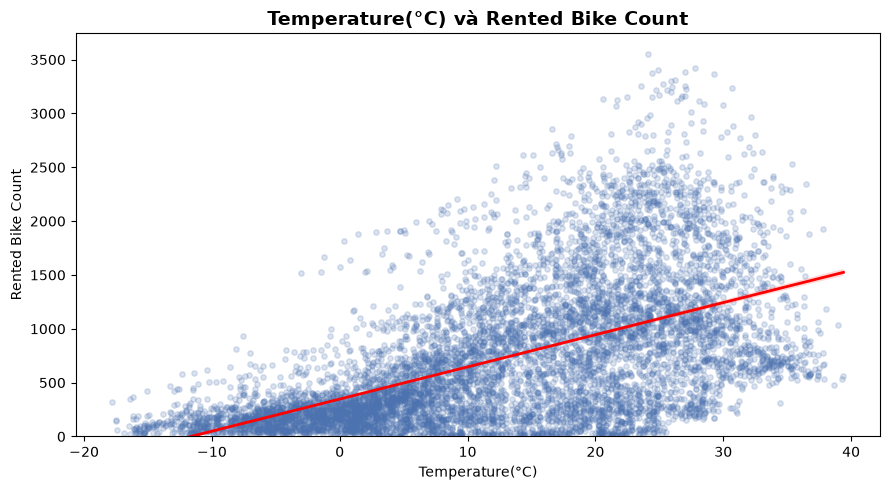

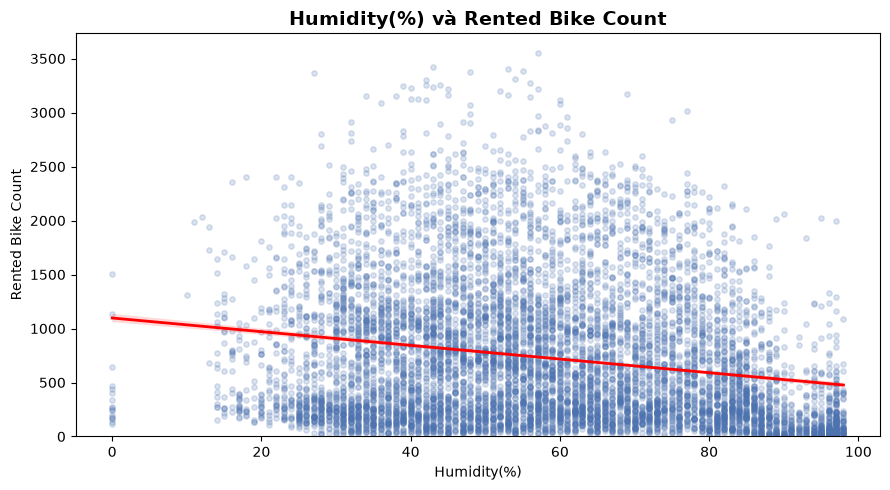

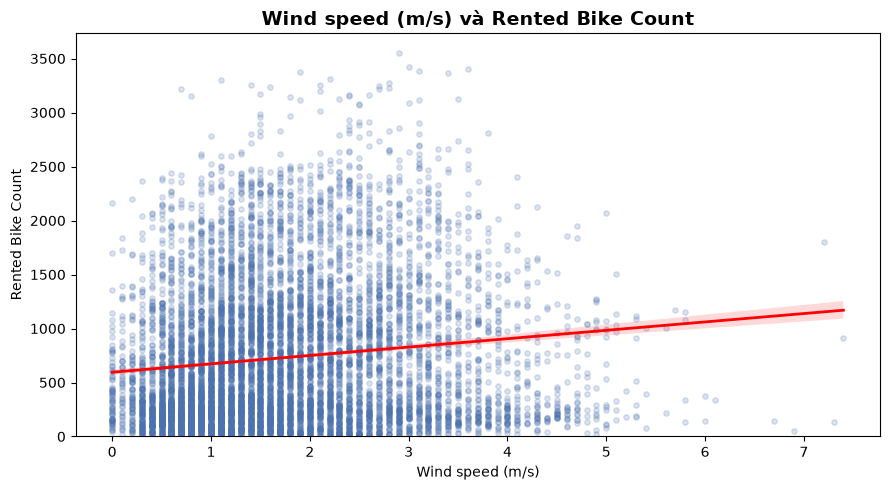

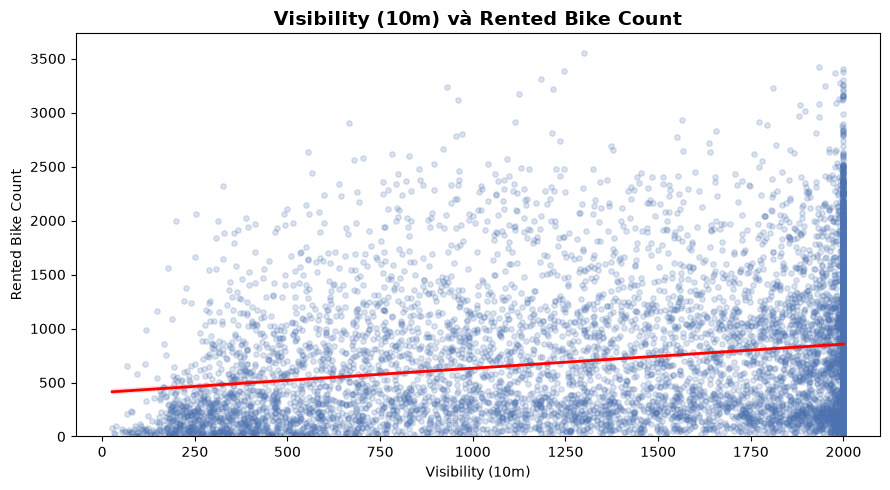

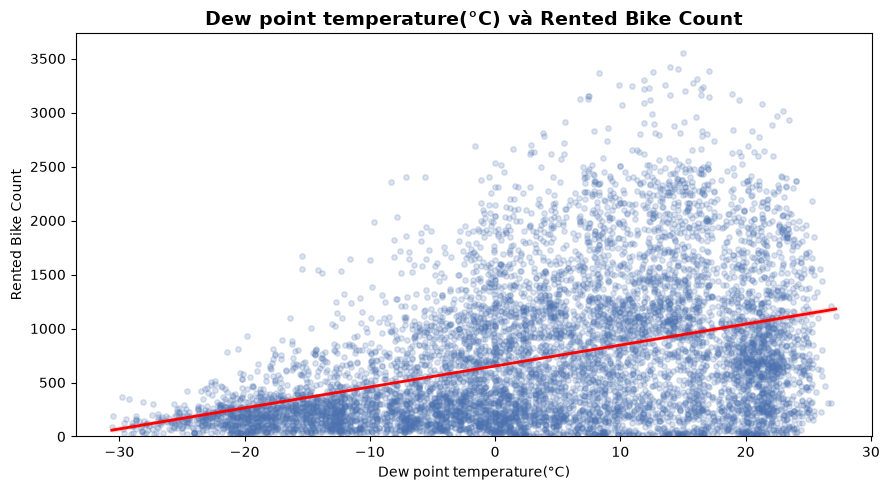

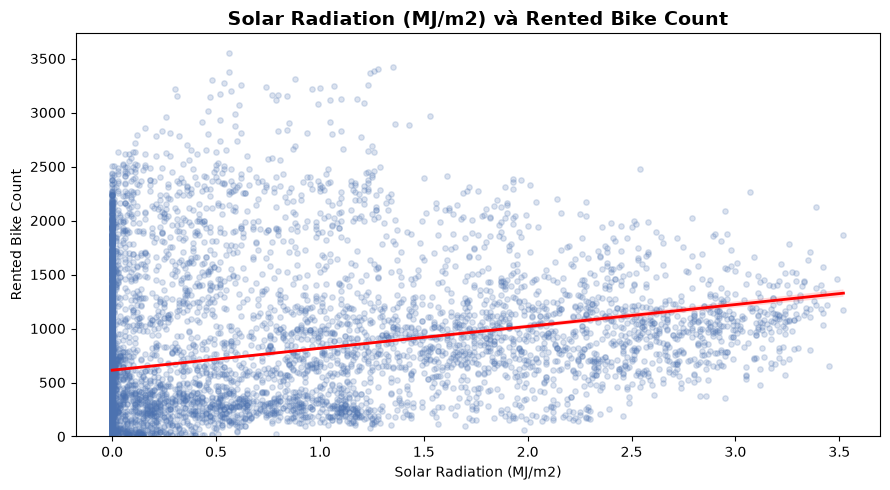

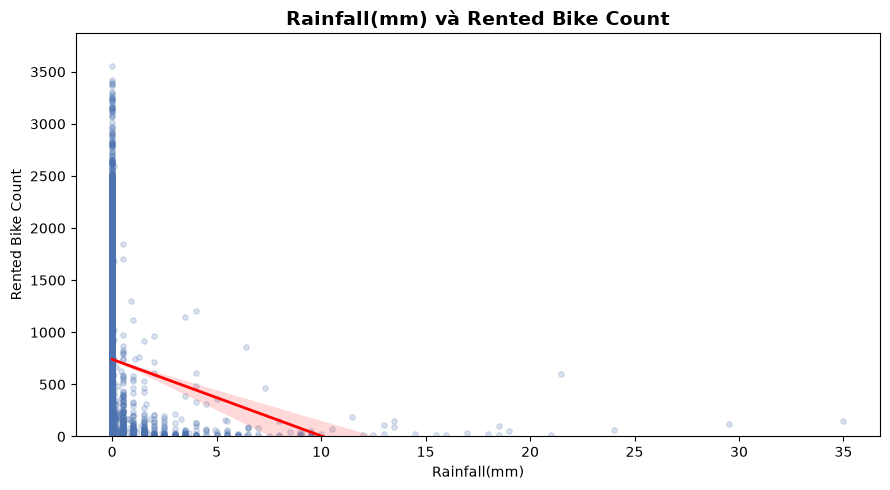

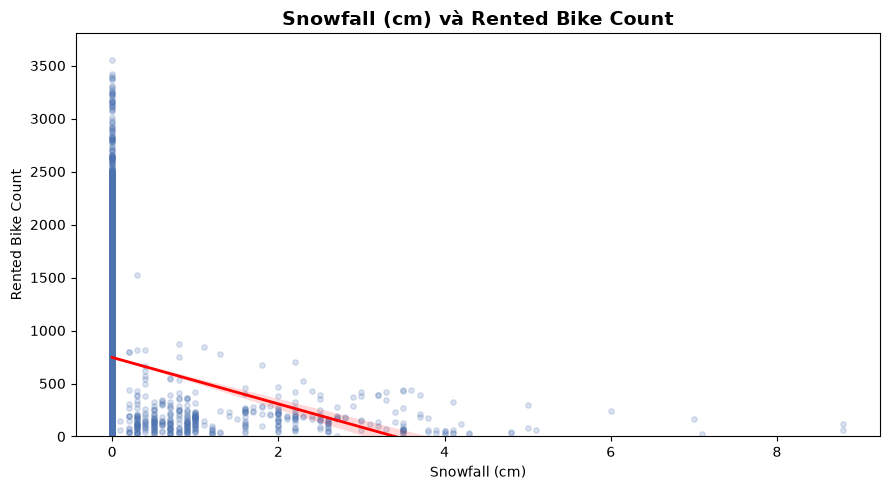

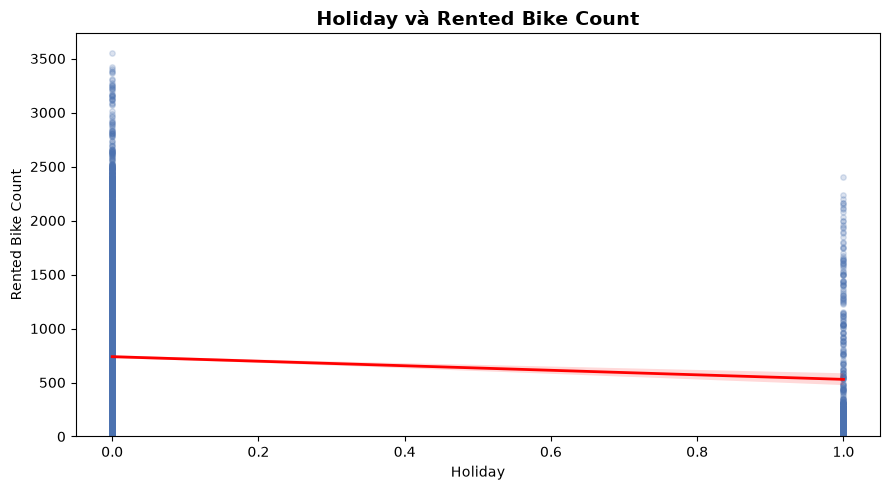

In [35]:
target_column = "rented-bike-count"
related_columns = df.select_dtypes(include="number").columns.drop(target_column)

for column_name in related_columns:
    friendly_x = get_friendly_name(column_name)
    friendly_y = get_friendly_name(target_column)
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.regplot(
        data=df,
        x=column_name,
        y=target_column,
        scatter_kws={"alpha": 0.2, "s": 15, "color": "#4C72B0"},
        line_kws={"color": "red", "linewidth": 2},
        ax=ax,
    )
    ax.set(xlabel=friendly_x, ylabel=friendly_y, ylim=(0, None))
    ax.set_title(f"{friendly_x} và {friendly_y}", fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()

### Ma trận tương quan Pearson

,pearson_r
humidity,-0.201973
snowfall,-0.151611
rainfall,-0.128626
holiday,-0.070070
wind-speed,0.125022
visibility,0.212323
solar-radiation,0.273862
dew-point-temperature,0.400263
hour,0.425256
temperature,0.562740


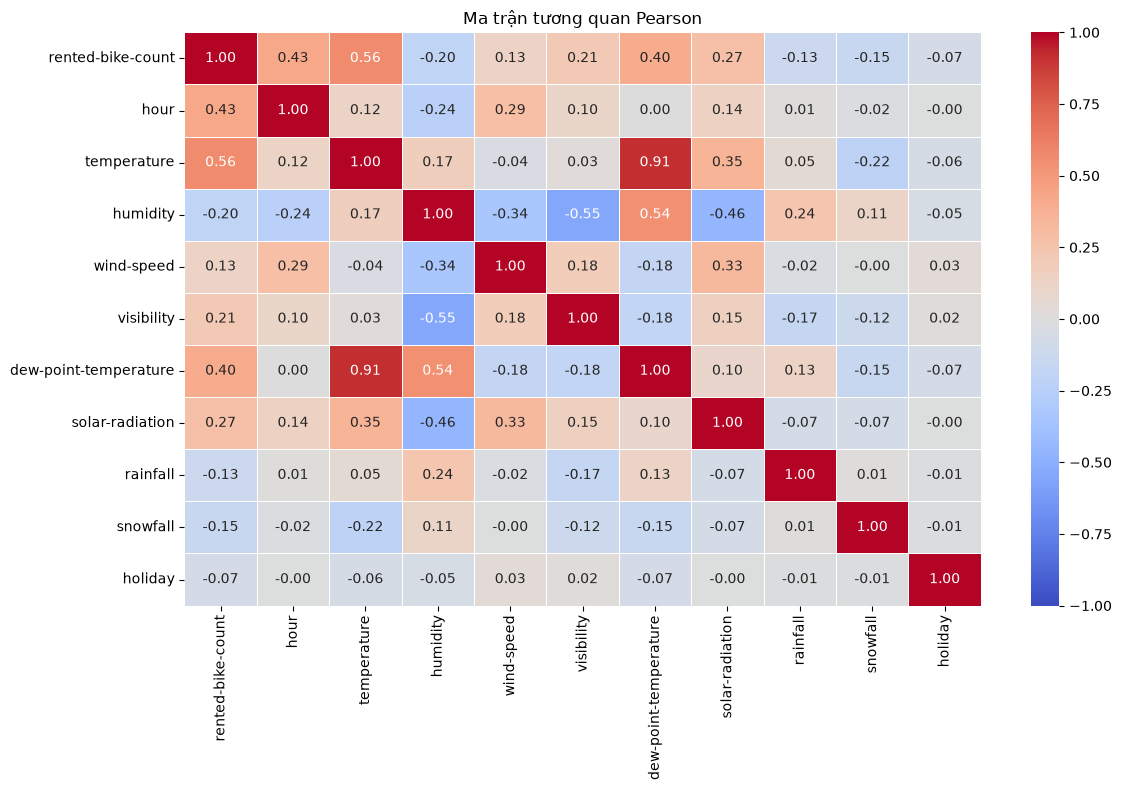

In [25]:
numeric_df = df.select_dtypes(include="number")
correlation_matrix = numeric_df.corr(method="pearson")
target_correlations = (
    correlation_matrix["rented-bike-count"]
    .drop("rented-bike-count")
    .sort_values()
)
display(target_correlations.rename("pearson_r").to_frame())

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Ma trận tương quan Pearson")
fig.tight_layout()
plt.show()

**Nhận xét:** Số lượt thuê tương quan tuyến tính dương mức vừa (r = 0,56) với 
nhiệt độ; âm yếu (r = -0,20) với độ ẩm. Đây là liên hệ hai biến không chứng minh 
nhân quả; biến giờ có tính chu kỳ mà đường hồi quy thẳng không mô tả đầy đủ.

### So sánh số lượt thuê theo mùa

In [29]:
season_summary = (
    df.groupby("seasons")["rented-bike-count"]
    .agg(count="count", mean="mean", median="median", std="std")
    .round(2)
)
display(season_summary)

,count,mean,median,std
seasons,,,,
Autumn,1937,924.11,856.0,617.55
Spring,2160,746.25,599.0,618.67
Summer,2208,1034.07,905.5,690.24
Winter,2160,225.54,203.0,150.37


### Kiểm định ANOVA một yếu tố

- $H_0$: trung bình số lượt thuê bằng nhau giữa bốn mùa.
- $H_1$: ít nhất một mùa có trung bình số lượt thuê khác biệt.

Mức ý nghĩa được chọn là 0,05. ANOVA chỉ kiểm tra khác biệt tổng thể, không xác định cặp mùa nào khác nhau; kết quả theo giờ cũng cần được diễn giải thận trọng vì các quan sát liên tiếp có thể không độc lập.

In [34]:
season_groups = [
    group["rented-bike-count"].to_numpy()
    for _, group in df.groupby("seasons", sort=True)
]

alpha = 0.05
f_statistic, p_value = stats.f_oneway(*season_groups)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3e}")
if p_value < alpha:
    print("Bác bỏ H0: có bằng chứng rằng trung bình không giống nhau ở tất cả các mùa.")
else:
    print("Chưa đủ bằng chứng để bác bỏ H0 ở mức ý nghĩa 0,05.")

F-statistic: 875.60
P-value: 0.000e+00
Bác bỏ H0: có bằng chứng rằng trung bình không giống nhau ở tất cả các mùa.
